<a href="https://colab.research.google.com/github/KIRANRW9/Data-Analytics-Portfolio/blob/repo-exercise/TCS_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-22-ca9324e9647d>:25: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



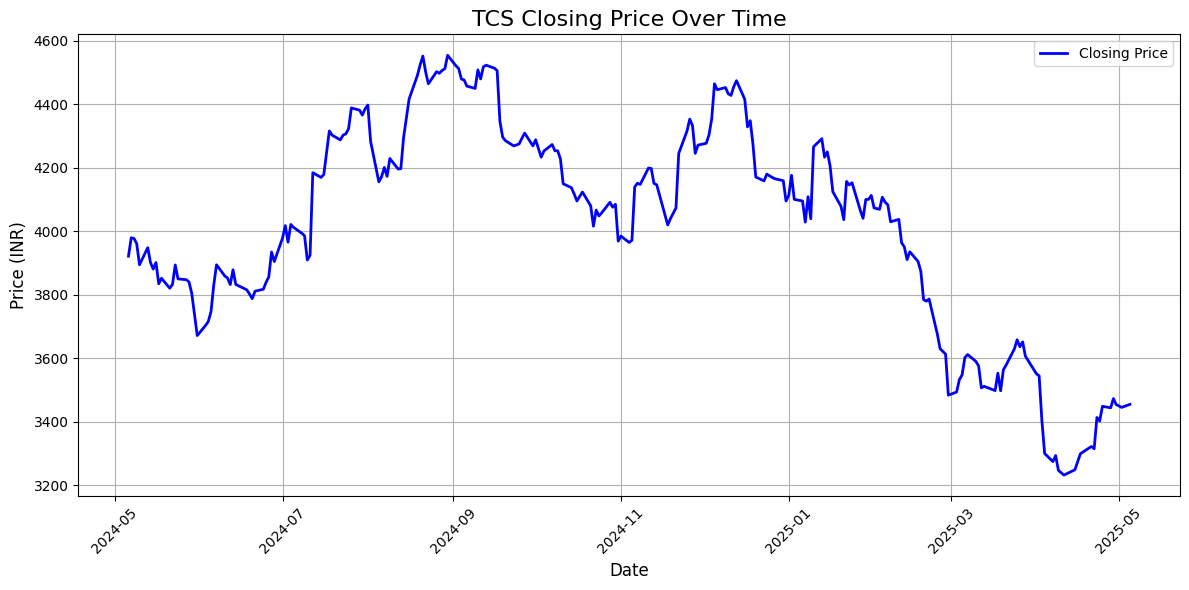

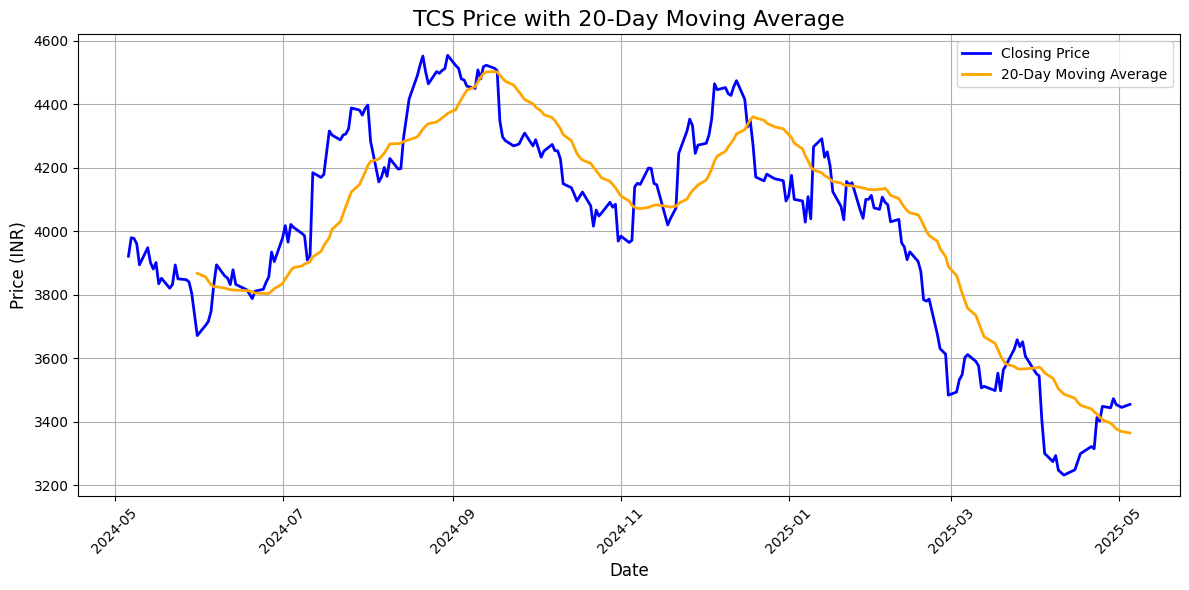

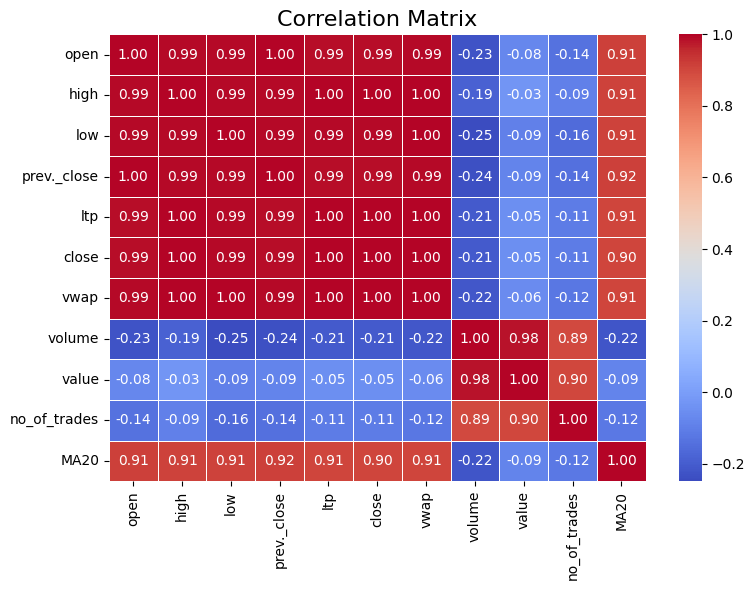

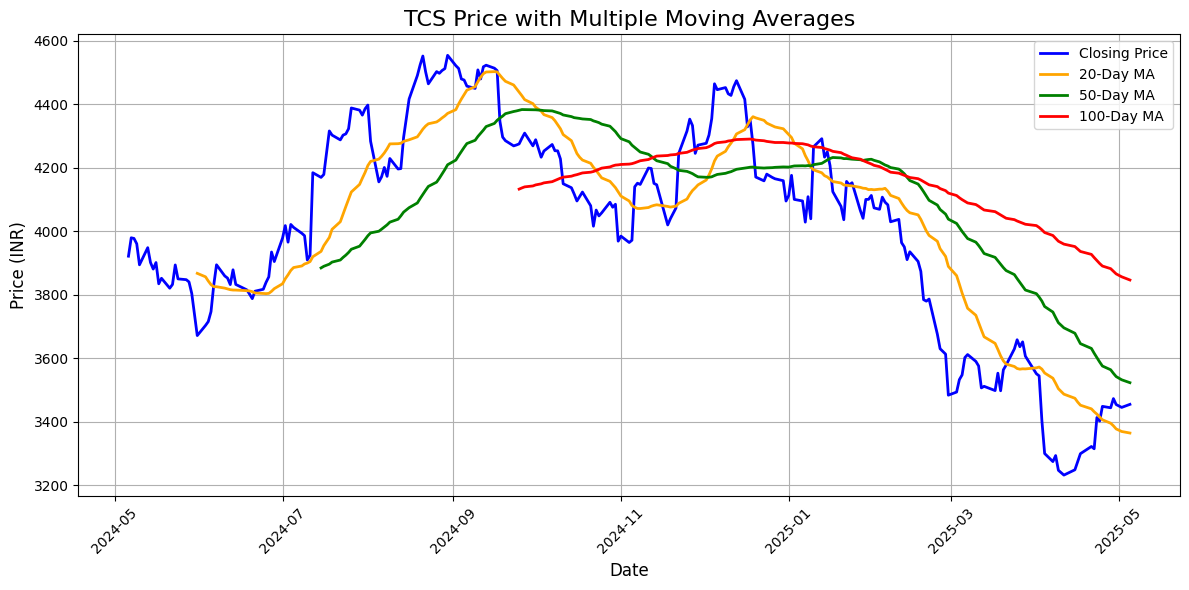

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset (use a CSV file or predefined sample)
file_path = 'TCS.csv'  # Specify your file path here
df = pd.read_csv(file_path)

# Step 2: Clean the dataset
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]  # Standardize column names

# Remove commas and convert columns to numeric
cols_to_clean = ['open', 'high', 'low', 'prev._close', 'ltp', 'close', 'vwap', 'volume', 'value', 'no_of_trades']
df[cols_to_clean] = df[cols_to_clean].replace({',': ''}, regex=True)
df[cols_to_clean] = df[cols_to_clean].apply(pd.to_numeric)

# Step 3: Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%Y')

# Step 4: Sort by date and set it as the index
df = df.sort_values(by='date')
df.set_index('date', inplace=True)

# Step 5: Handle missing values (optional, can drop or fill based on use case)
df.fillna(method='ffill', inplace=True)  # Forward fill missing data

# Step 6: Plot closing price over time
plt.figure(figsize=(12, 6))
plt.plot(df['close'], label='Closing Price', color='blue', linewidth=2)
plt.title('TCS Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 7: Moving average (20-day by default, can adjust)
df['MA20'] = df['close'].rolling(window=20).mean()

# Plot with Moving Average
plt.figure(figsize=(12, 6))
plt.plot(df['close'], label='Closing Price', color='blue', linewidth=2)
plt.plot(df['MA20'], label='20-Day Moving Average', color='orange', linewidth=2)
plt.title('TCS Price with 20-Day Moving Average', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 8: Correlation heatmap of numerical columns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# Step 9: Additional Trend Analysis (Optional)
# You can add more moving averages like 50-day and 100-day
df['MA50'] = df['close'].rolling(window=50).mean()
df['MA100'] = df['close'].rolling(window=100).mean()

# Plotting all Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df['close'], label='Closing Price', color='blue', linewidth=2)
plt.plot(df['MA20'], label='20-Day MA', color='orange', linewidth=2)
plt.plot(df['MA50'], label='50-Day MA', color='green', linewidth=2)
plt.plot(df['MA100'], label='100-Day MA', color='red', linewidth=2)
plt.title('TCS Price with Multiple Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

